In [1]:
import numpy as np
import time
import os
import h5py
import inspect
from tqdm import tqdm
import sys
import matplotlib.pyplot as plt
import warnings
from typing import List
import qutip as qt
from scipy.interpolate import interp1d
from scipy.constants import Planck
import cvxpy as cp
import random

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Style

plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 17
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.frameon'] = False

In [2]:
def covariance_matrix(usb_arr, modes):
    V = np.zeros((len(usb_arr), 2 * len(modes), 2 * len(modes)))
    for part_idx in range(len(usb_arr)):
        real_part = np.real(usb_arr[part_idx])
        imag_part = np.imag(usb_arr[part_idx])
        coord_arr = [(real_part[:, v], imag_part[:, v]) for v in range(len(modes))]
        coord_arr = np.concatenate(coord_arr, axis=0)
        V[part_idx] = np.cov(coord_arr)
    return V

def covariance_matrix2(usb_arr):
    real_part = np.real(usb_arr)
    imag_part = np.imag(usb_arr)

    # Stack quadratures: [Re0, Im0, Re1, Im1, ...]
    xp_mat = np.empty((usb_arr.shape[0], usb_arr.shape[1]*2))
    xp_mat[:, 0::2] = real_part
    xp_mat[:, 1::2] = imag_part

    # Covariance over samples
    return np.cov(xp_mat, rowvar=False)

### ROTATION ###
def cov_rotation(cov_mat, theta):
    """Rotate covariance matrix by angle theta (radians)"""
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(
        [[c, -s],
        [s, c]]
    )
    
    N = cov_mat.shape[0] // 2
    R_big = np.zeros((2*N, 2*N))
    for i in range(N):
        R_big[2*i:2*i+2, 2*i:2*i+2] = R
    
    return R_big @ cov_mat @ R_big.T


def plot_cov_matrix(V, modes, zmax_, zmin_, figure, axis):
    listI = ['$I_{' + str(i - len(modes) // 2) + '}$' for i in range(len(modes))]
    xlabels = np.arange(-1, 2 * len(modes), 2)
    ylabels = np.arange(0, 2 * len(modes), 2)
    x = np.arange(-1, 2 * len(modes) - 1, 1)
    grid_arr = np.arange(0.5, 2 * len(modes) + 0.5, 1)

    a = axis.pcolormesh(x, x, np.flipud(V), shading='nearest', cmap='RdBu_r', vmax=zmax_, vmin=zmin_)
    figure.colorbar(a, aspect=50, label='Signal amplitude [photons]')
    # plt.xticks(xlabels[::4], listI[::4])
    # plt.yticks(ylabels[::2], np.flipud(listI)[::2])
    # axis.set_xticks(grid_arr[0::2], minor=True)
    # axis.set_yticks(grid_arr[0::2], minor=True)
    # axis.grid(True, which='minor', axis='both', linestyle='-', color='w', linewidth=2)


def symplecticity_test(mat):
    S = mat + 0.5j * symp_mat
    eigenvalues, eigenvectors = np.linalg.eig(S)
    return eigenvalues, eigenvectors

verbose = True

#fs_to_V2 = 0.45825089808266056

In [3]:
# Load calibration data - G, n
file_calib = r'/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/Planck/Planck Run 2026-05 2/planck_2026-05.hdf5'


with h5py.File(file_calib, "r") as dataset:
    sample_grp = dataset
    myrun = list(sample_grp.keys())[0]
    run_grp = sample_grp[myrun]

    # Frequency array
    freq_arr_c = np.asarray(run_grp['freq arr'])

    # Gain and added number of photons (n)
    gain_c = np.asarray(run_grp['gain'])
    n_c = np.asarray(run_grp['n'])
    
    # Gain and added number of photons standard deviations
    gain_std_c = np.asarray(run_grp['std gain'])
    n_std_c = np.asarray(run_grp['std n'])

# indices = np.concatenate(
#     (
#          np.arange(0, 80),
#         np.arange(110, 191)
#     )
# )

# freq_arr_c = freq_arr_c[indices]
# gain_c = gain_c[indices]
# n_c = n_c[indices]
# gain_std_c = gain_std_c[indices]
# n_std_c = n_std_c[indices]

In [4]:
# Load covariance pump sweep data

folder  = r'/media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-05/Covariance/'
file = sorted(
        (f for f in os.listdir(folder) if f.endswith('.hdf5')),
        key=lambda f: os.path.getmtime(os.path.join(folder, f))
    )[-1]

file = os.path.join(folder, file)

# file = r'/media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-04/Covariance/2026-04-14_15_05_45.hdf5'

with h5py.File(file, 'r') as dataset:
    run = list(dataset.keys())[0]
#    meas_type = list(dataset[meas_type].keys())[0]
    amp_pump = np.sort(dataset['{}'.format(run)].attrs['amp_pump'])

print(file)

/media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-05/Covariance/2026-05-14_11_43_49.hdf5


  0%|                                                    | 0/11 [00:00<?, ?it/s]

Processing pump amplitude: 0.0
Experimental Cov Mat computed
Quantum Cov Mat computed


  9%|███▉                                       | 1/11 [02:44<27:21, 164.14s/it]

cov matrices saved
Processing pump amplitude: 0.1
Experimental Cov Mat computed
Quantum Cov Mat computed


 18%|███████▊                                   | 2/11 [05:27<24:31, 163.47s/it]

...

cov matrices saved
Processing pump amplitude: 0.9
Experimental Cov Mat computed
Quantum Cov Mat computed


 91%|██████████████████████████████████████▏   | 10/11 [25:38<02:38, 158.68s/it]

cov matrices saved
Processing pump amplitude: 1.0
Experimental Cov Mat computed
Quantum Cov Mat computed


100%|██████████████████████████████████████████| 11/11 [28:18<00:00, 154.43s/it]

cov matrices saved


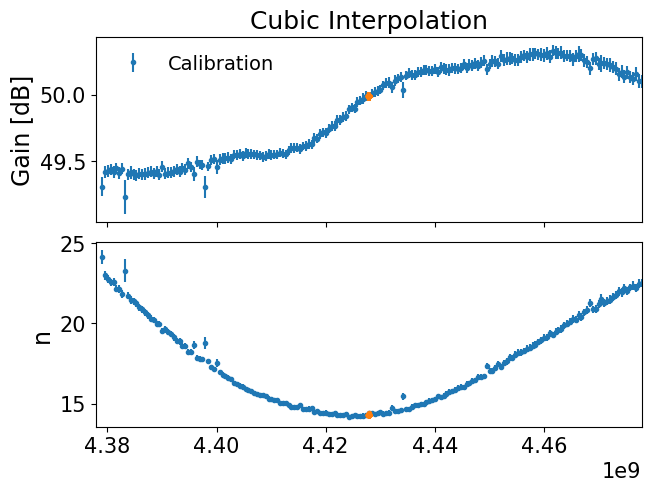

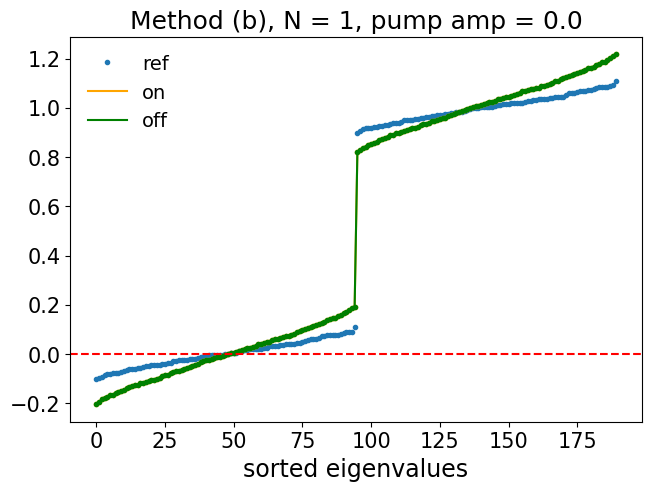

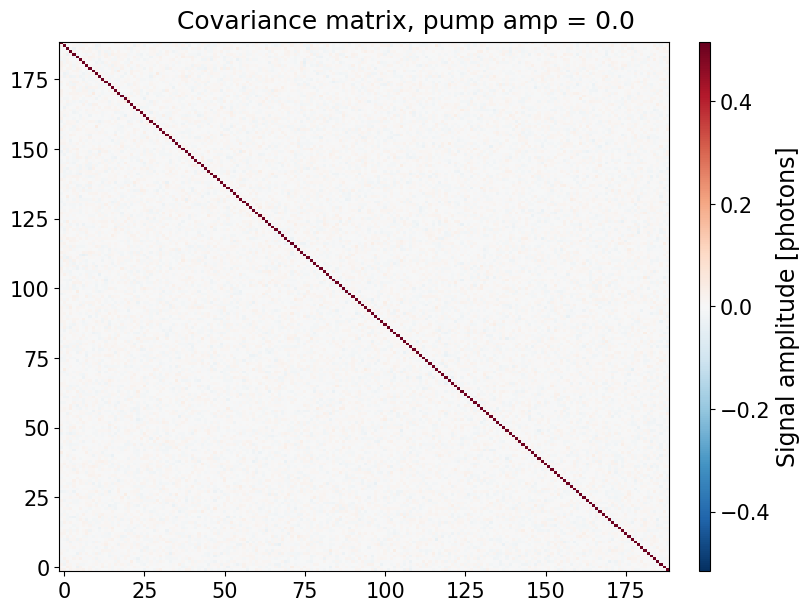

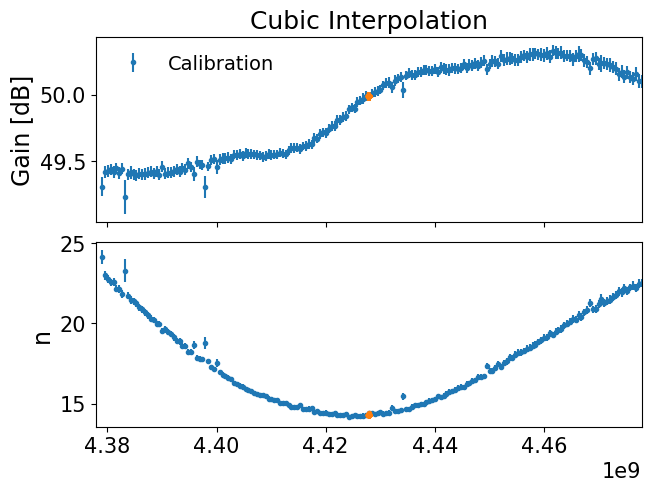

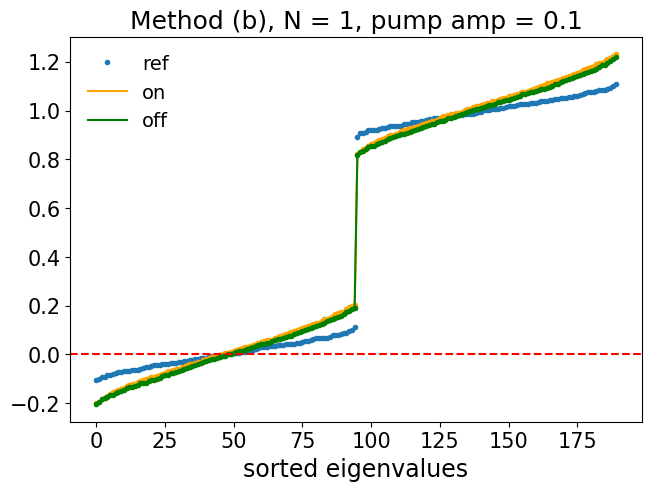

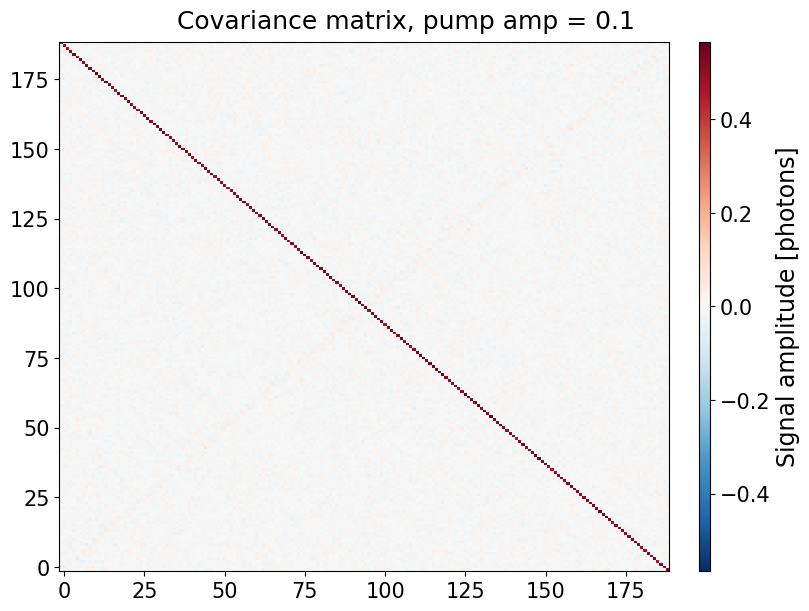

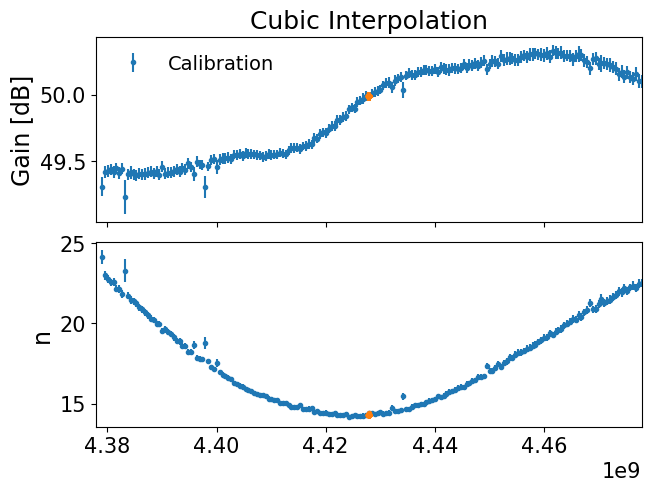

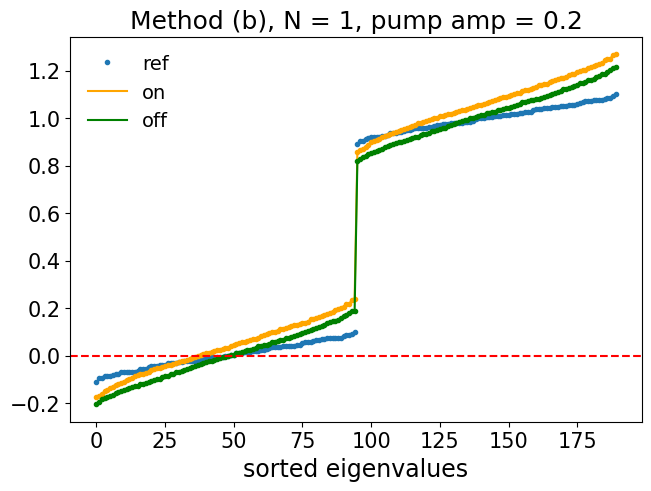

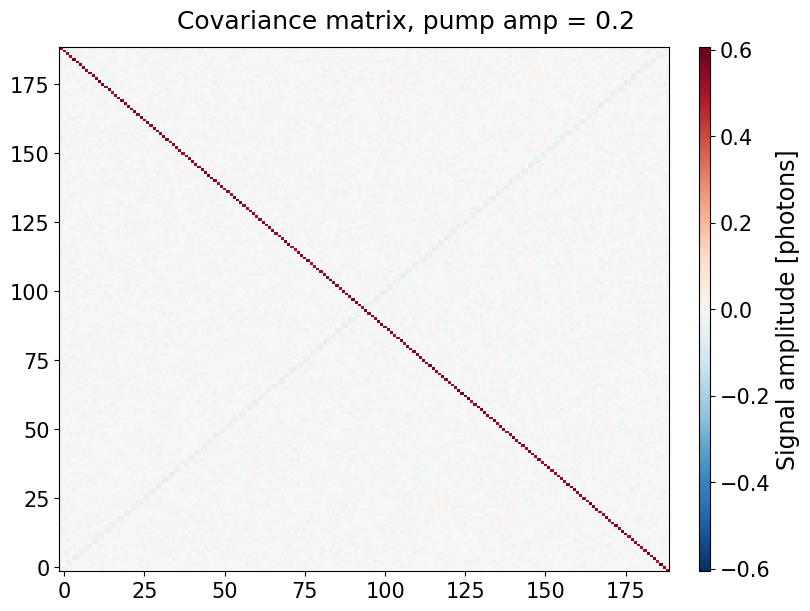

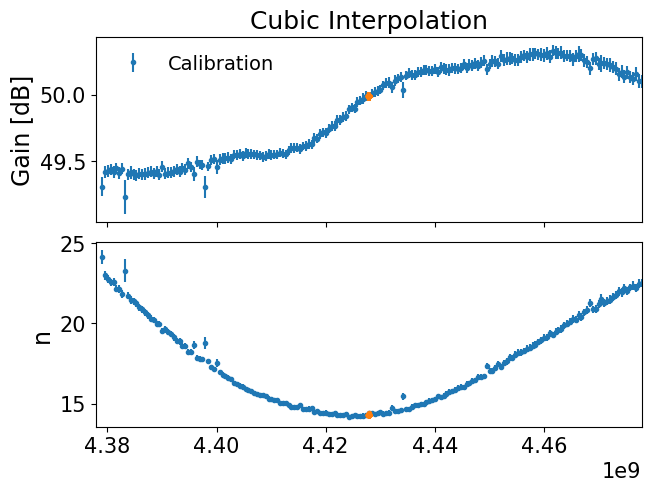

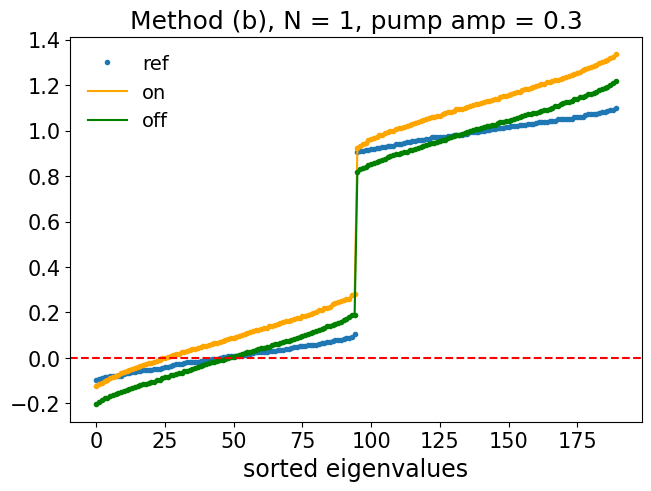

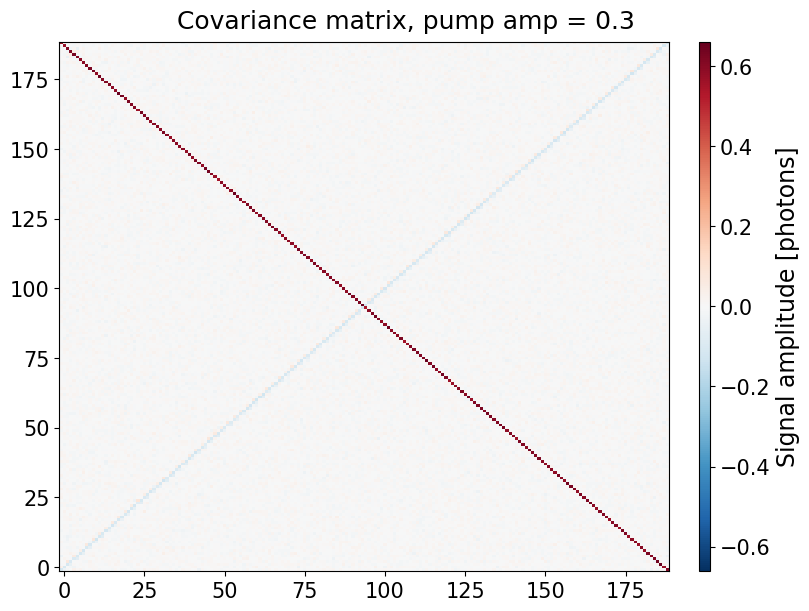

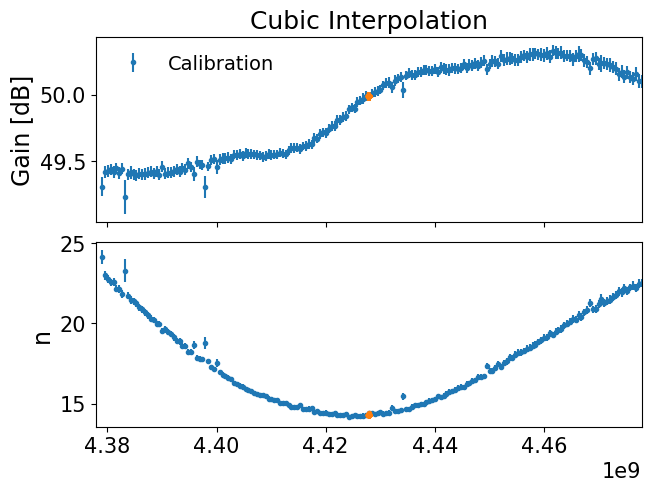

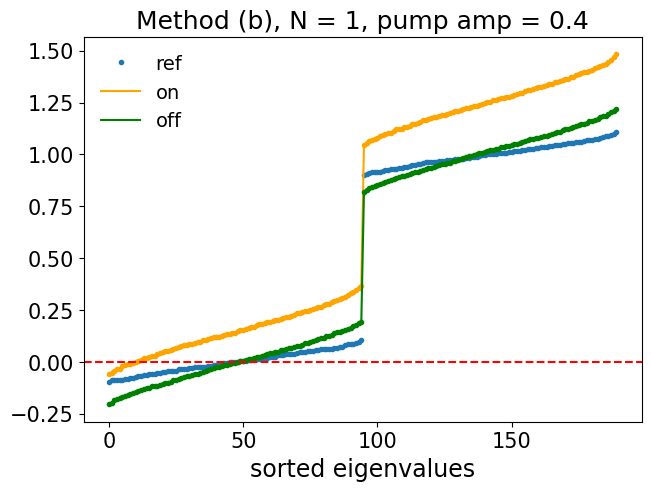

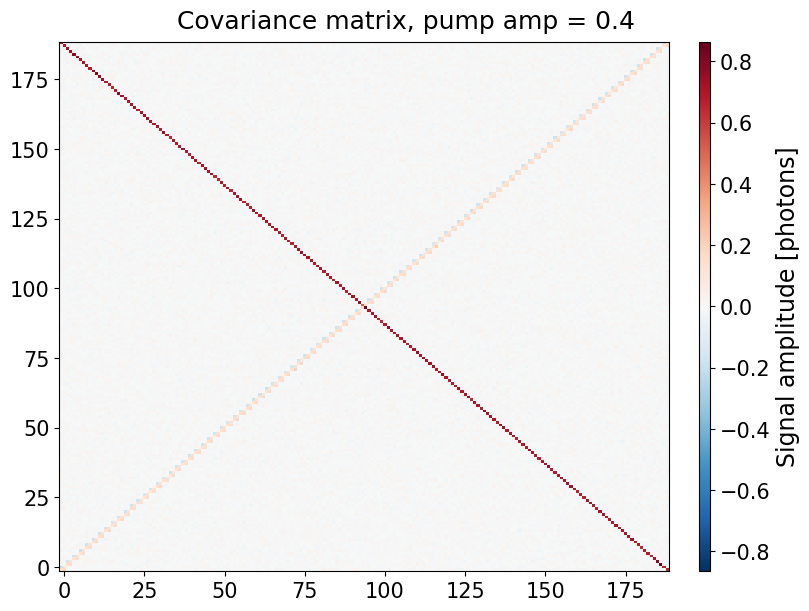

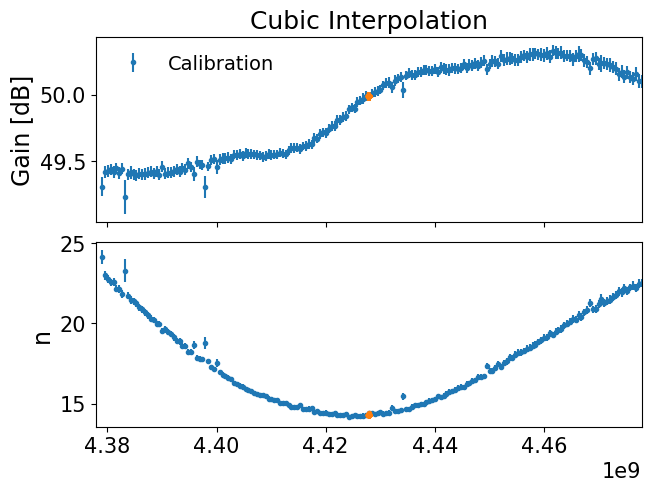

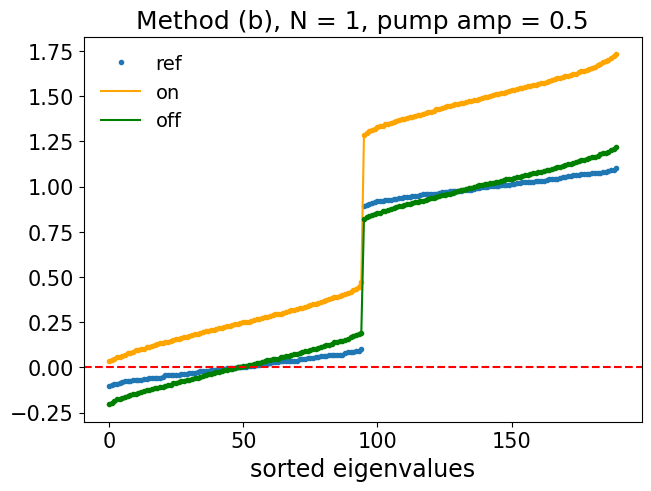

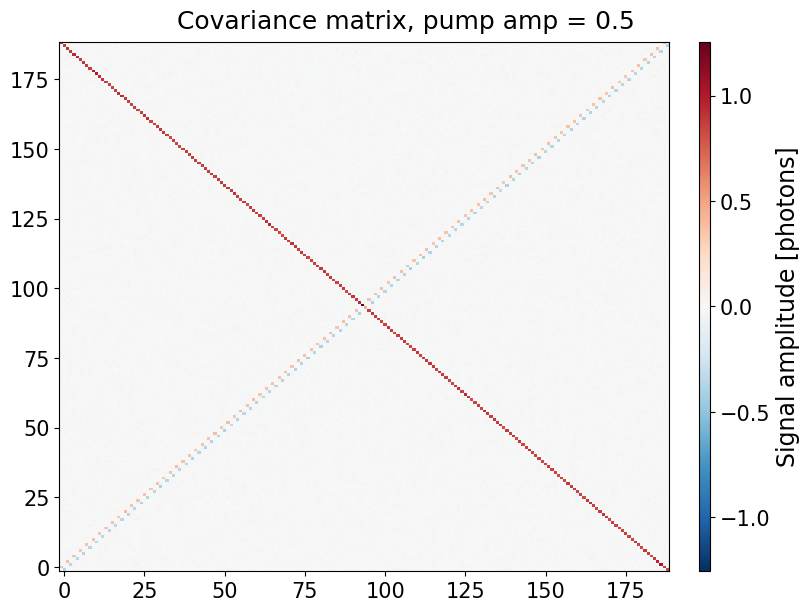

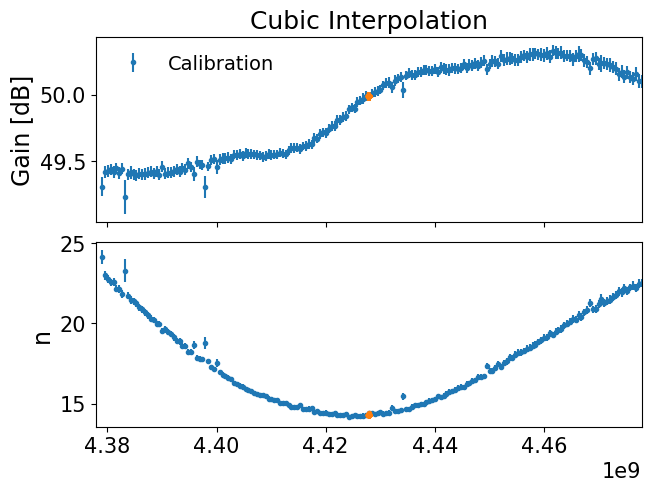

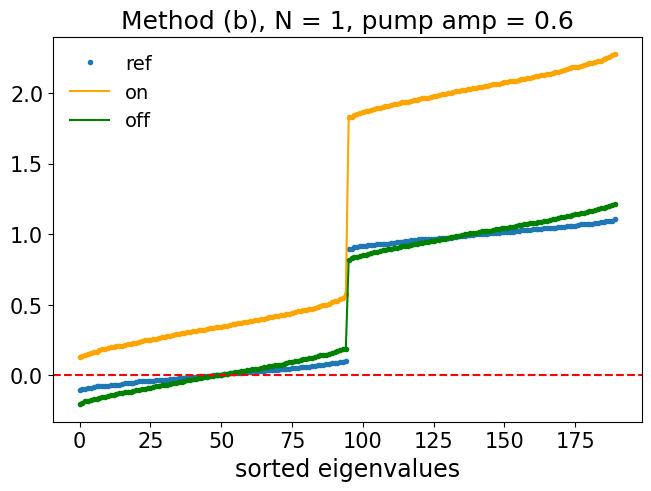

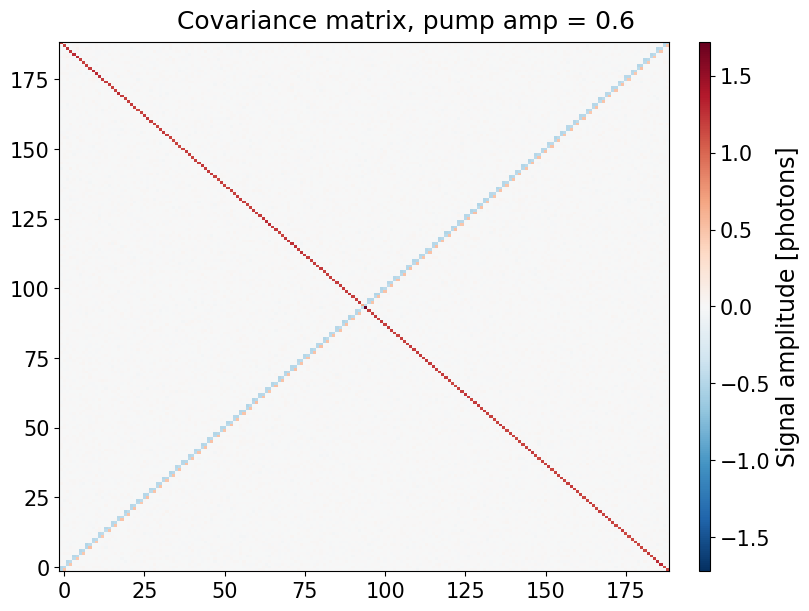

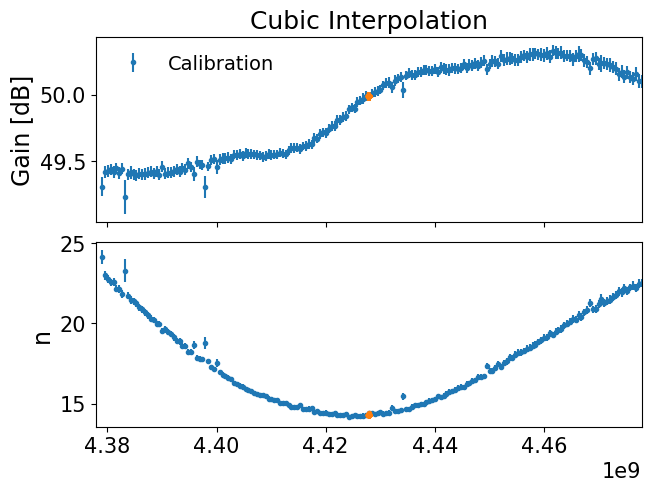

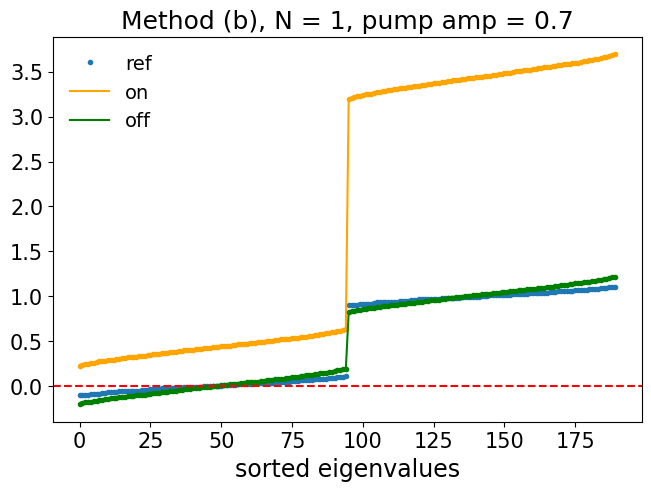

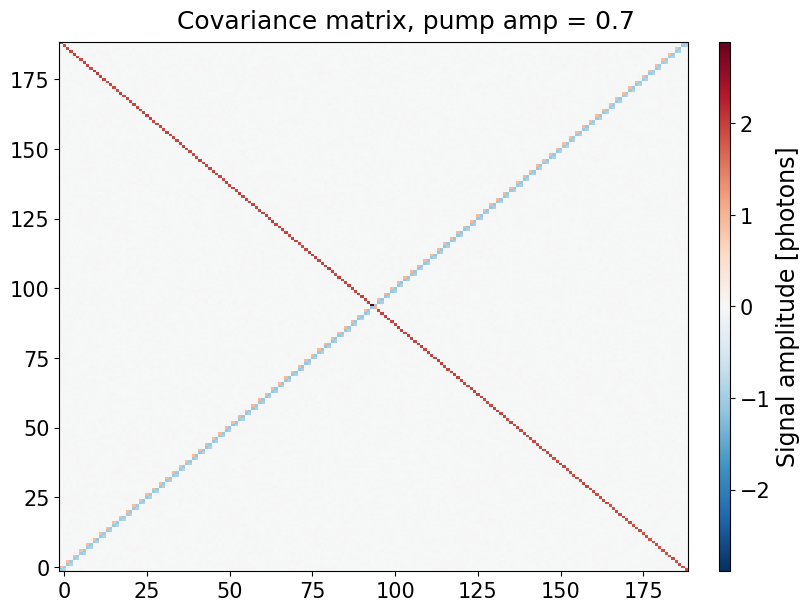

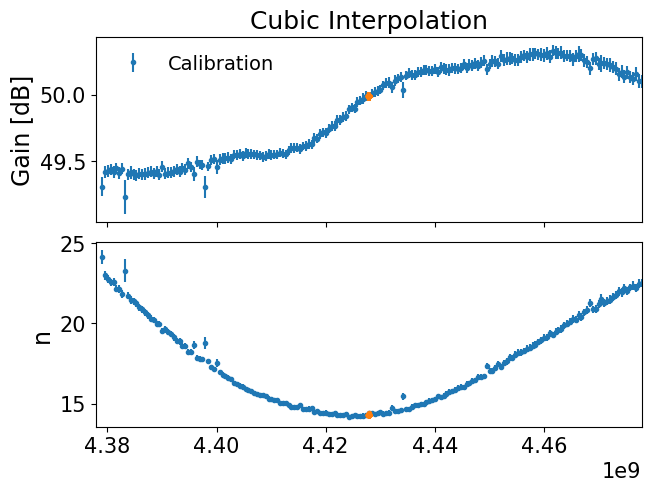

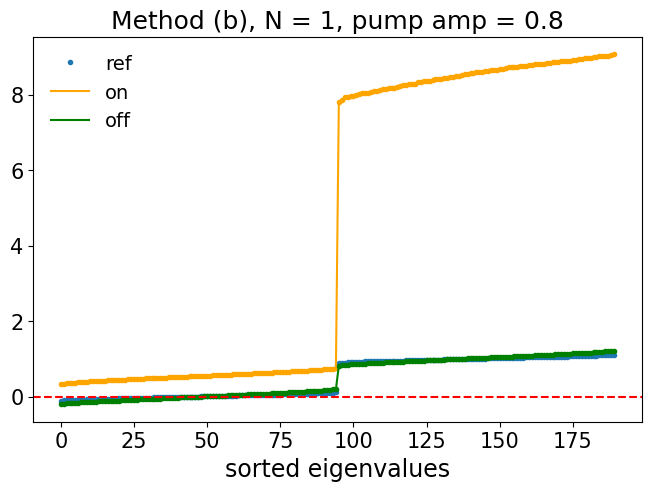

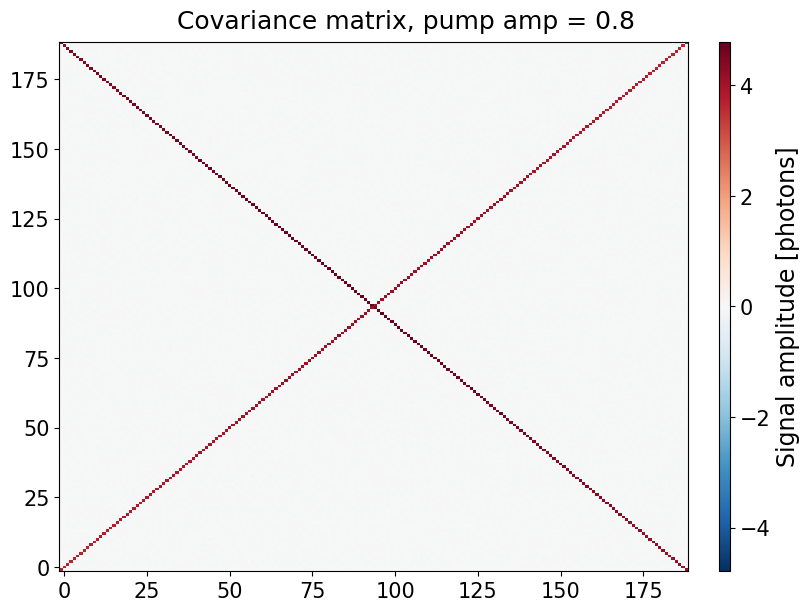

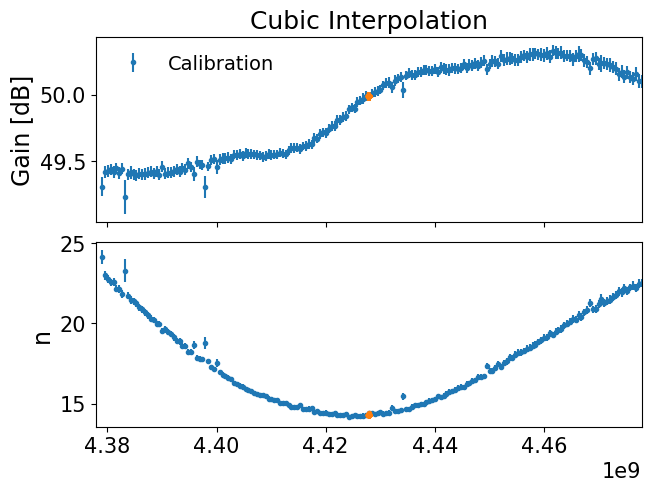

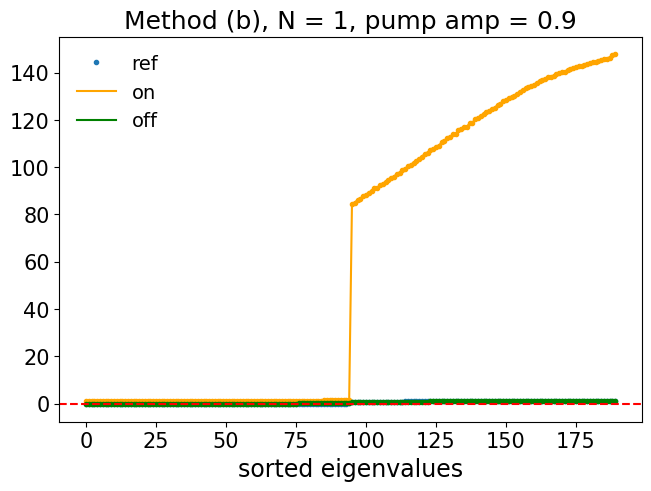

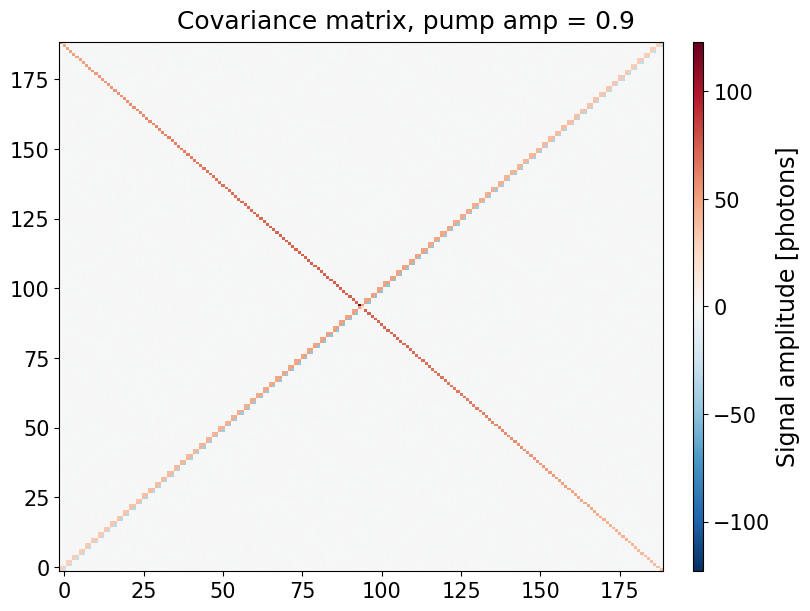

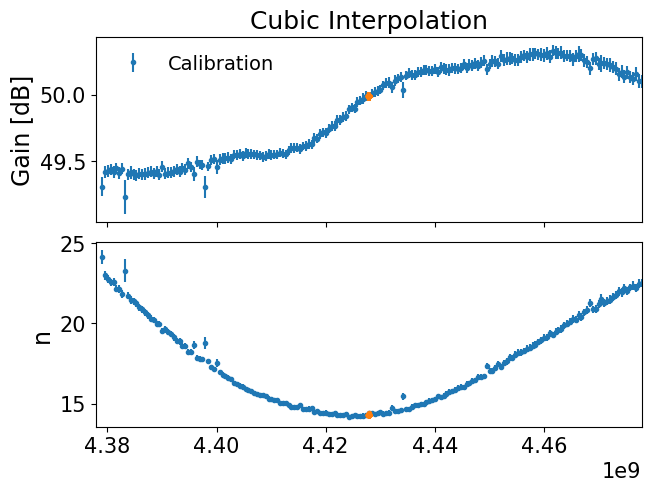

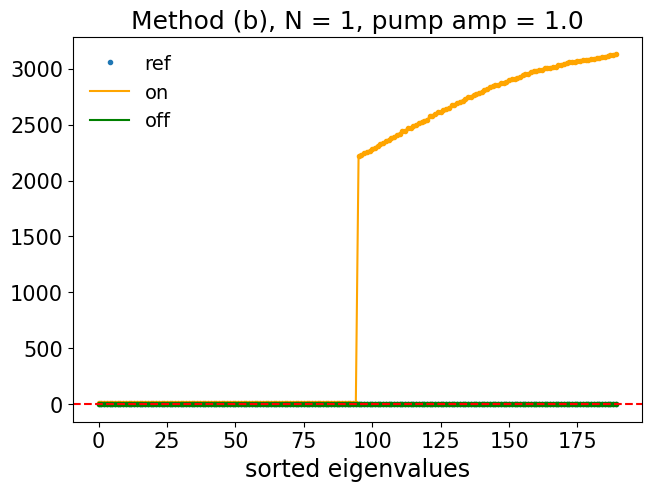

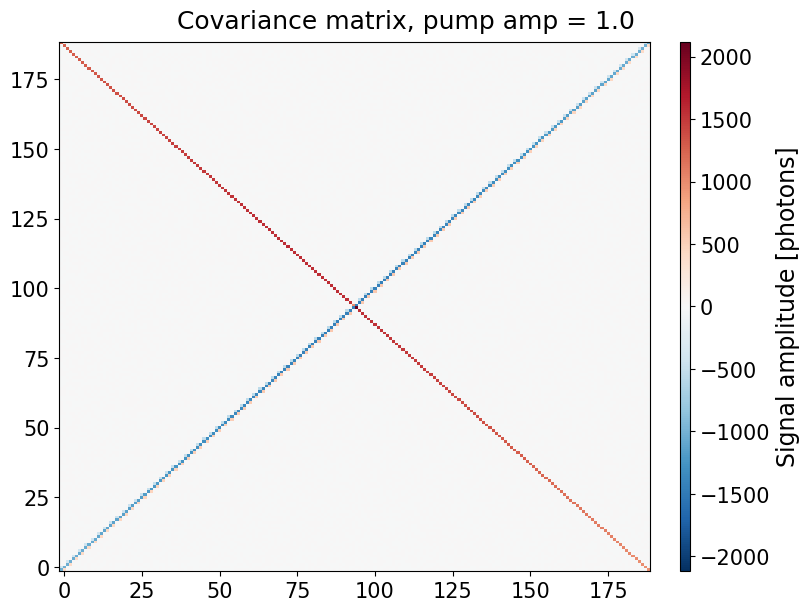

In [5]:
with tqdm(total=(len(amp_pump)), ncols=80) as pbar:
    for pump_amp_idx in range(len(amp_pump)):

        print('Processing pump amplitude: ' + str(np.round(amp_pump[pump_amp_idx], 3)))

        idx_str = '{}/{}'.format(run, pump_amp_idx)
        attr_str = '{}'.format(run)

        # Load metadata only — never pull the full USB ON/OFF arrays into memory
        with h5py.File(file, 'r') as dataset:
            freq_arr = np.asarray(dataset[idx_str]['freq comb'])
            df = dataset[attr_str].attrs['df']
            Npixels = dataset[attr_str].attrs['Npixels']
            N_total = dataset[idx_str]['USB ON'].shape[0]

        # Symplectic matrix
        J_matrix = np.array([[0, 1], [-1, 0]])
        symp_mat = np.block([[(J_matrix if v == j else np.zeros_like(J_matrix, dtype=complex))
                            for v in range(len(freq_arr))] for j in range(len(freq_arr))])

        Zc = 50
        pts_chunk = Npixels
        N_chunks = (N_total + pts_chunk - 1) // pts_chunk

        # Combined per-mode scale: raw voltage → quadrature in sqrt(photons).
        # Absorbs sqrt(0.56) and the photon conversion 1/sqrt(Zc*df*Planck*freq).
        scale_n = np.sqrt(0.56 / (2 * Zc * df * Planck * freq_arr))  # shape (N_modes,)

        # Stream covariance matrices from HDF5 one chunk at a time.
        # Peak RAM = one chunk × 2 (on/off) — the full dataset is never in memory.
        Vexp_on_list, Vexp_off_list = [], []
        Mexp_on = Mexp_off = None

        with h5py.File(file, 'r') as dataset:
            dset_on  = dataset[idx_str]['USB ON']
            dset_off = dataset[idx_str]['USB OFF']
            N_modes  = len(freq_arr)

            for i in range(N_chunks):
                start = i * pts_chunk
                end   = min((i + 1) * pts_chunk, N_total)

                # Read one chunk and scale to sqrt(photons)
                chunk_on  = dset_on[start:end]  * scale_n   # (pts, N_modes), complex
                chunk_off = dset_off[start:end] * scale_n

                # Interleaved quadrature matrix: columns = [Re0, Im0, Re1, Im1, ...]
                n_pts = end - start
                xp_on  = np.empty((n_pts, 2 * N_modes))
                xp_on[:, 0::2]  = np.real(chunk_on)
                xp_on[:, 1::2]  = np.imag(chunk_on)

                xp_off = np.empty((n_pts, 2 * N_modes))
                xp_off[:, 0::2] = np.real(chunk_off)
                xp_off[:, 1::2] = np.imag(chunk_off)

                if i == 0:
                    Mexp_on  = np.mean(xp_on,  axis=0)
                    Mexp_off = np.mean(xp_off, axis=0)

                Vexp_on_list.append(np.cov(xp_on,  rowvar=False))
                Vexp_off_list.append(np.cov(xp_off, rowvar=False))

        Vexp_on  = np.array(Vexp_on_list)   # (N_chunks, 2*N_modes, 2*N_modes), in photon number
        Vexp_off = np.array(Vexp_off_list)

        if verbose:
            print('Experimental Cov Mat computed')

        ##############################################################################
        # INTERPOLATION OF THE GAIN AND ADDED PHOTON NUMBER AT OPERATIONAL FREQUENCIES
        ##############################################################################

        # Interpolation gain function
        f_gain = interp1d(freq_arr_c, gain_c, kind='linear', fill_value="extrapolate")
        # Gain at the measured frequencies
        gain = f_gain(freq_arr)
        # Interpolation n function
        f_n = interp1d(freq_arr_c, n_c, kind='zero', fill_value="extrapolate")
        # n at the measured frequencies
        n = f_n(freq_arr)

        # ERRORS
        # Gain of the signal error bars
        f_gain_up = interp1d(freq_arr_c, gain_c + gain_std_c, kind='cubic', fill_value="extrapolate")
        gain_up = f_gain_up(freq_arr)
        f_gain_down = interp1d(freq_arr_c, gain_c - gain_std_c, kind='cubic', fill_value="extrapolate")
        gain_down = f_gain_down(freq_arr)
        gain_std = (gain_up - gain_down) / 2
        # n error bars
        f_n_up = interp1d(freq_arr_c, n_c + n_std_c, kind='cubic', fill_value="extrapolate")
        n_up = f_n_up(freq_arr)
        f_n_down = interp1d(freq_arr_c, n_c - n_std_c, kind='cubic', fill_value="extrapolate")
        n_down = f_n_down(freq_arr)
        n_std = (n_up - n_down) / 2
        # correlated errors between G and n (they come from the same fit)
        #f_gn = interp1d(freq_arr_c, gn_corr_c,  kind='cubic', fill_value="extrapolate")
        # Gain at the measured frequencies
        #gn_corr = f_gn(freq_arr)D:/Planck LKIPA Cycle 2026-05/Planck-Data/planck_2026-05.hdf5

        ################ Plot of the gain and n #########################
        fig, ax = plt.subplots(2, 1, sharex=True)
        ax[0].errorbar(freq_arr_c, gain_c, yerr=gain_std_c, fmt='.', label='Calibration')
        ax[0].errorbar(freq_arr, gain, yerr=gain_std, fmt='.')
        ax[0].set_ylabel('Gain [dB]')
        ax[0].set_title('Cubic Interpolation')
        ax[1].errorbar(freq_arr_c, n_c, yerr=n_std_c, fmt='.', label='Calibration')
        ax[1].errorbar(freq_arr, n, yerr=n_std, fmt='.')
        ax[1].set_xlim(np.min(freq_arr)-0.05e9, np.max(freq_arr)+0.05e9)
        ax[1].set_ylabel('n')
        ax[0].legend()

        ##############################################################################
        # RECONSTRUCTION OF THE MEAN
        ##############################################################################

        G = np.diag(np.diag(10 ** (np.repeat(gain, 2, axis=0) / 10)))
        Mq_on = Mexp_on / np.sqrt(G)
        Mq_off = Mexp_off / np.sqrt(G)

        ##############################################################################
        # RECONSTRUCTION OF THE COVARIANCE MATRIX
        ##############################################################################

        # indices of the diagonal 
        rows, cols = np.diag_indices_from(Vexp_on[0])

        # METHOD (a) Vq = G^{-1/2} * Vexp * G^{-1/2} - (n + 1/2)

        # Matrix building
        # G (gain) matrix
        G = np.diag(10 ** (np.repeat(gain, 2, axis=0) / 10))
        # G^{-1/2}: two-sided gain correction (correct for covariance matrices)
        G_sqrt_inv = np.diag(1.0 / np.sqrt(np.diag(G)))
        # N (added number of photons) matrix
        n_xp = np.repeat(n, 2, axis=0)
        N = np.diag(n_xp)

        # Quantum covariance matrices
        Vq_on_a = G_sqrt_inv @ Vexp_on @ G_sqrt_inv - (N + 1 / 2 * np.identity(len(N)))
        Vq_off_a = G_sqrt_inv @ Vexp_off @ G_sqrt_inv - (N + 1 / 2 * np.identity(len(N)))

        # check if quantum cov mat is symplectic
        symp_Vq_on_a, _ = symplecticity_test(Vq_on_a)
        symp_Vq_on_a = np.sort(np.real(symp_Vq_on_a), axis=-1)
        symp_Vq_off_a, _ = symplecticity_test(Vq_off_a)
        symp_Vq_off_a = np.sort(np.real(symp_Vq_off_a), axis=-1)

        # Reference matrix
        mu, sigma = 0.0, np.std(np.triu(Vq_off_a, k=1) + np.tril(Vq_off_a, k=-1))
        Vq_test = mu + sigma * np.random.randn(len(cols), len(rows))
        Vq_test[rows, cols] += np.full_like(Vq_test[0], 0.5)
        symp_Vq_test, _ = symplecticity_test(Vq_test)
        symp_Vq_test = np.sort(np.real(symp_Vq_test))

        # METHOD (b) Vq_off^ii = 1 / (2n+2) * (G^{-1/2} * Vexp * G^{-1/2})^ii
        #            Vq_off^ij = (G^{-1/2} * Vexp * G^{-1/2})^ij
        #            Vq_on = G^{-1/2} (Vexp_on - Vexp_off) G^{-1/2} + Vq_off

        # Scale pump-off cov matrix by G^{-1/2} from both sides
        Vq_off_b = G_sqrt_inv @ Vexp_off @ G_sqrt_inv
        # Rescale even more the diagonal by 1/(2n+2) to get Quantum cov matrix in photon number
        Vq_off_b[:, rows, cols] = 1 / (2 * n_xp + 2) * np.diagonal(Vq_off_b, axis1=1, axis2=2)

        # Calculate the pump-on quantum cov matrix as
        Vq_on_b = G_sqrt_inv @ (Vexp_on - Vexp_off) @ G_sqrt_inv  + Vq_off_b
        #Vq_on_b = Vexp_on
        # check if quantum cov mat is symplectic
        symp_Vq_on_b, _ = symplecticity_test(Vq_on_b)
        symp_Vq_on_b = np.sort(np.real(symp_Vq_on_b), axis=-1)
        symp_Vq_off_b, _ = symplecticity_test(Vq_off_b)
        symp_Vq_off_b = np.sort(np.real(symp_Vq_off_b), axis=-1)

        # Reference matrix
        mu, sigma = np.mean(np.triu(Vq_off_b, k=1) + np.tril(Vq_off_b, k=-1)), np.std(np.triu(Vq_off_b, k=1) + np.tril(Vq_off_b, k=-1))
        Vq_test = mu + sigma * np.random.randn(len(cols), len(rows))
        Vq_test[rows, cols] += np.full_like(Vq_test[0], 0.5)
        symp_Vq_test, _ = symplecticity_test(Vq_test)
        symp_Vq_test = np.sort(np.real(symp_Vq_test))

        if verbose:
            print('Quantum Cov Mat computed')


        # ERROR ANALYSIS (check notes for derivation)
        # Matrix building
        sG = np.diag(10 ** (np.repeat(gain_std, 2, axis=0) / 10))
        sn = np.diag(np.repeat(n_std, 2, axis=0))
        #sGn = np.diag(np.repeat(gn_corr, 2, axis=0))

        sVexp_on = np.std(Vexp_on, axis=0)**2
        sVexp_off = np.std(Vexp_off, axis=0)**2

        # Errors (error in n is the main source of error by few orders of magnitude)
        e_G = (G_sqrt_inv @ G_sqrt_inv @ (Vexp_on - Vexp_off) @ G_sqrt_inv @ sG @ G_sqrt_inv)**2
        e_Vexp_on = (G_sqrt_inv @ sVexp_on @ G_sqrt_inv)**2
        e_Vexp_off = (G_sqrt_inv @ (-sVexp_off) @ G_sqrt_inv)**2

        # off-diagonal errors
        e_Vq_off = ((G_sqrt_inv @ G_sqrt_inv @ Vexp_off @ G_sqrt_inv @ sG @ G_sqrt_inv)**2 +
                    (G_sqrt_inv @ sVexp_off @ G_sqrt_inv)**2)

        # diagonal errors
        e_Vq_off[:, rows, cols] = np.diagonal(
                                            (G_sqrt_inv @ G_sqrt_inv @ (1 / (2 * n_xp + 2) * Vexp_off) @ G_sqrt_inv @ sG @ G_sqrt_inv)**2 +
                                            (G_sqrt_inv @ (1 / (2 * n_xp + 2) * sVexp_off) @ G_sqrt_inv)**2 +
                                            (G_sqrt_inv @ (1/ (2 * (n_xp + 1)**2) * Vexp_off) @ G_sqrt_inv @ sn)**2,
                                            axis1=-2, axis2=-1)
#        e_Gn = 2 * np.matmul(np.matmul(np.linalg.inv(G**2), 1 / (2 * n_xp + 2) * Vexp_off), 
#                            np.matmul(np.linalg.inv(G), 1 / (2 * (n_xp + 1)**2) * Vexp_off)) * sGn

        sVq_on_b = np.sqrt(e_G + e_Vexp_on + e_Vexp_off + e_Vq_off)# + e_Gn)
        sVq_off_b = np.sqrt(e_Vq_off + e_Vexp_off)

        # Compute symplecticity test considering errors (don't think it says a lot)
        Vq_on_b_emax = Vq_on_b + sVq_on_b
        Vq_on_b_emin = Vq_on_b - sVq_on_b

        symp_Vq_on_b_emax, _ = symplecticity_test(Vq_on_b_emax)
        symp_Vq_on_b_emax = np.sort(np.real(symp_Vq_on_b_emax), axis=-1)
        symp_Vq_on_b_emin, _ = symplecticity_test(Vq_on_b_emin)
        symp_Vq_on_b_emin = np.sort(np.real(symp_Vq_on_b_emin), axis=-1)


        ####################### Plot the eigenvalues mean through all the chunks #########################
        fig, ax = plt.subplots(1)
        ax.plot(symp_Vq_test, '.', label='ref')
        ax.plot(symp_Vq_on_b.T, '.', c='orange')
        ax.plot(np.mean(symp_Vq_on_b, axis=0), '-', c='orange', label='on')
#        ax.plot(np.mean(symp_Vq_on_b_emax, axis=0)[1:-1], '--', c='darkorange')
#        ax.plot(np.mean(symp_Vq_on_b_emin, axis=0)[1:-1], '--', c='darkorange')
        ax.plot(symp_Vq_off_b.T, '.', c='green')
        ax.plot(np.mean(symp_Vq_off_b, axis=0), '-', c='green', label='off')
        # ax.plot(symp_Vq_norm_b.T, '.', c='purple')
        # ax.plot(np.mean(symp_Vq_norm_b, axis=0), '-', c='purple', label='norm')
        ax.axhline(0, c='red', ls='--')
        ax.set_title('Method (b), N = ' + str(N_chunks) + ', pump amp = ' + str(np.round(amp_pump[pump_amp_idx], 3)))
        ax.set_xlabel('sorted eigenvalues')
        ax.legend()

        ########################### Covariance matrix plot ##############################
        zmax = np.max(Vq_on_b[0])
        zmin = -zmax
        fig, ax = plt.subplots(1, figsize=(8, 6))
        #plot_cov_matrix(Vq_on_b[random.randint(0, len(Vq_on_b)-1)], freq_arr, zmax, zmin, fig, ax)
        plot_cov_matrix(np.mean(Vq_on_b, axis=0), freq_arr, zmax, zmin, fig, ax)
        fig.suptitle('Covariance matrix, pump amp = ' + str(np.round(amp_pump[pump_amp_idx], 3)))

        # save data in hdf5 file
        # save data in hdf5 file
        save = True

        if save:

            def overwrite_dataset(h5file, name, data):
                """
                Delete dataset if it exists, then recreate it.
                """
                if name in h5file:
                    del h5file[name]

                h5file.create_dataset(
                    name,
                    data=data,
                    dtype=float
                )

            with h5py.File(file, 'a') as dataset:

                # String handles
                Vexp_on_data_str = f"{idx_str}/Vexp on"
                Vq_on_data_str = f"{idx_str}/Vq on"
                std_Vq_on_data_str = f"{idx_str}/sVp on"
                Mq_on_data_str = f"{idx_str}/meanq on"

                Vexp_off_data_str = f"{idx_str}/Vexp off"
                Vq_off_data_str = f"{idx_str}/Vq off"
                std_Vq_off_data_str = f"{idx_str}/sVp off"
                Mq_off_data_str = f"{idx_str}/meanq off"

                attr_chunk_str = f"{idx_str}"

                # -----------------------------
                # OVERWRITE DATASETS IF NEEDED
                # -----------------------------

                overwrite_dataset(dataset, Vexp_on_data_str, Vexp_on[0])
                overwrite_dataset(dataset, Vq_on_data_str, Vq_on_b[0])
                overwrite_dataset(dataset, std_Vq_on_data_str, sVq_on_b)
                overwrite_dataset(dataset, Mq_on_data_str, Mq_on)

                overwrite_dataset(dataset, Vexp_off_data_str, Vexp_off[0])
                overwrite_dataset(dataset, Vq_off_data_str, Vq_off_b[0])
                overwrite_dataset(dataset, std_Vq_off_data_str, sVq_off_b)
                overwrite_dataset(dataset, Mq_off_data_str, Mq_off)

                # -----------------------------
                # ATTRIBUTES
                # -----------------------------

                dataset[attr_chunk_str].attrs["N chunks"] = N_chunks

                dataset[Vexp_on_data_str].attrs["Unit"] = "n"
                dataset[Vq_on_data_str].attrs["Unit"] = "n"

                if verbose:
                    print('cov matrices saved')

        pbar.update(1)

plt.show()


# TESTING
----

## T.1 Raw covariance

In [20]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Uses G_sqrt_inv, N, Zc, df, freq_arr, idx_str, pts_chunk from the last main-loop iteration.
# To analyse a different amplitude: change pump_amp_idx and re-run the main loop.

# Scale: raw voltage → quadrature in sqrt(photons), with factor-of-2 normalisation
scale_test = np.sqrt(0.56 / (2 * Zc * df * Planck * freq_arr))  # shape (N_modes,)

# Load the SAME window as the covariance matrix plotted in the main loop (Vq_on_b[0]).
# Using the full dataset averages away the anti-diagonal due to slow phase drift across
# the measurement — the same mechanism as chunk-averaging from the old approach.
# To explore a different window change the slice below, e.g. [pts_chunk:2*pts_chunk].

pump_amp_idx =8
idx_str = '{}/{}'.format(run, pump_amp_idx)

with h5py.File(file, 'r') as dataset:
    usb_off_raw = dataset[idx_str]['USB OFF'][:]   # load into memory while file is open
    usb_on_raw  = dataset[idx_str]['USB ON'][:]
    print('data acquired')
usb_off_scaled = usb_off_raw * scale_test
del usb_off_raw

V_raw_off = covariance_matrix2(usb_off_scaled)
del usb_off_scaled

usb_on_scaled = usb_on_raw * scale_test
del usb_on_raw

V_raw_on = covariance_matrix2(usb_on_scaled)
del usb_on_scaled

### PUMP OFF COVARIANCE IN PHOTON NUMBER ###
# DE-AMPLIFICATION
V_deamp_off = G_sqrt_inv @ V_raw_off @ G_sqrt_inv

# REMOVE ADDED PHOTONS
V_photons_off = V_deamp_off - N - 0.5 * np.eye(np.shape(N)[0])  #/ (2*np.diag(N + 1))

### PUMP ON COVARIANCE IN PHOTON NUMBER ###
V_photons_on = (G_sqrt_inv @ (V_raw_on - V_raw_off) @ G_sqrt_inv) + V_photons_off

data acquired


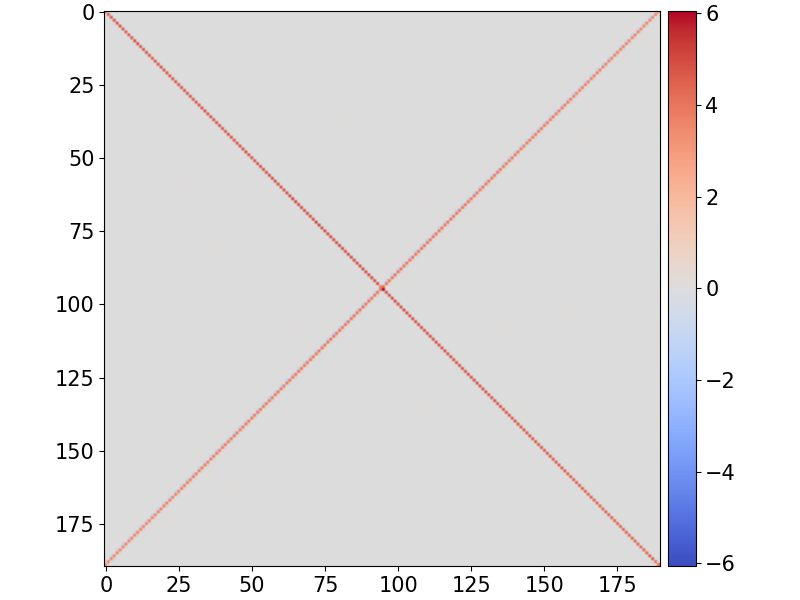

In [33]:
theta = 0.05*np.pi
plot = cov_rotation(V_photons_on, theta) #

vmax = np.max(plot)
vmin = -vmax

fig, ax = plt.subplots(figsize = (8, 6))

im = ax.imshow((plot), cmap='coolwarm', origin='upper', vmin=vmin, vmax=vmax)
# Colorbar exactly as tall as the matrix
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.08)
cbar = fig.colorbar(im, cax=cax)

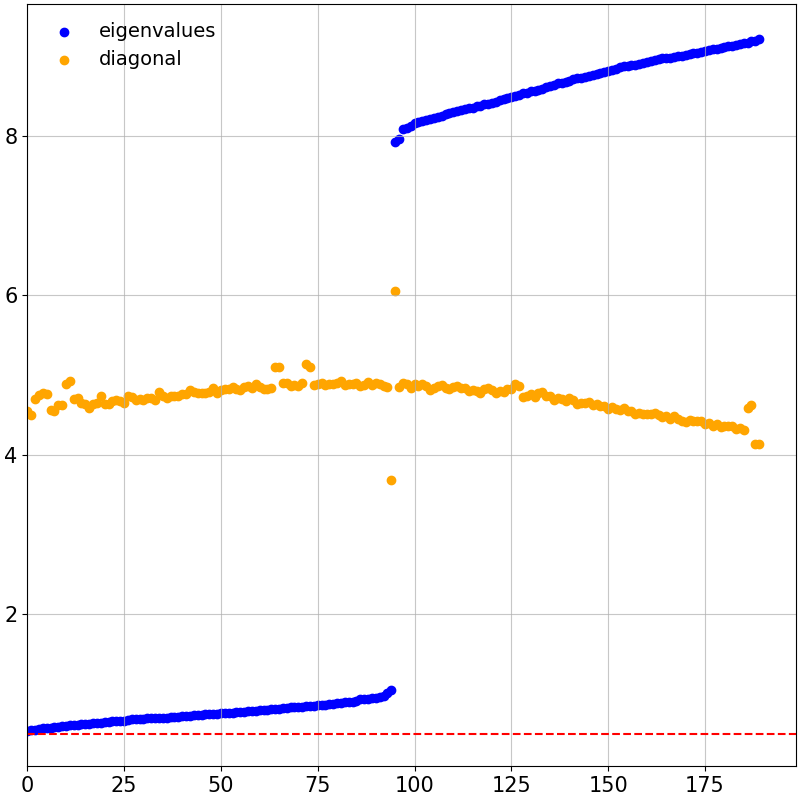

In [37]:
%matplotlib widget

v_eigs = (np.sort(np.linalg.eigvals(plot)))
v_diag = np.diag(plot)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(np.arange(2 * len(freq_arr)), v_eigs, label='eigenvalues', c='blue')
ax.scatter(np.arange(2 * len(freq_arr)), v_diag, label='diagonal', c='orange')
#ax.axhline(y =  + 1/2, c='green', ls='--')
ax.axhline(y=0.5, c='red', ls='--')

# Plot properties
ax.grid(alpha=0.7)
ax.set_xlim(left=0)
ax.legend()
#ax.set_ylim(bottom=0, top = 1)

## Squeezing v. Pump Power

In [35]:
pump_scan = False

if pump_scan:


    sqz_vals = np.zeros_like(amp_pump)

    for pump_amp_idx in range(len(amp_pump)):
        print('Processing pump amplitude: ' + str(np.round(amp_pump[pump_amp_idx], 3)))

        idx_str = '{}/{}'.format(run, pump_amp_idx)

        with h5py.File(file, 'r') as dataset:
            usb_off_raw = dataset[idx_str]['USB OFF'][:]   # load into memory while file is open
            usb_on_raw  = dataset[idx_str]['USB ON'][:]
            print('data acquired')
            usb_off_scaled = usb_off_raw * scale_test
            del usb_off_raw

            V_raw_off = covariance_matrix2(usb_off_scaled)
            del usb_off_scaled

            usb_on_scaled = usb_on_raw * scale_test
            del usb_on_raw

            V_raw_on = covariance_matrix2(usb_on_scaled)
            del usb_on_scaled

            ### PUMP OFF COVARIANCE IN PHOTON NUMBER ###
            # DE-AMPLIFICATION
            V_deamp_off = G_sqrt_inv @ V_raw_off @ G_sqrt_inv

            # REMOVE ADDED PHOTONS
            V_photons_off = V_deamp_off - N - 0.5 * np.eye(np.shape(N)[0])

            ### PUMP ON COVARIANCE IN PHOTON NUMBER ###
            V_photons_on = (G_sqrt_inv @ (V_raw_on - V_raw_off) @ G_sqrt_inv) + V_photons_off

            sqz_vals[pump_amp_idx] = (np.min(np.linalg.eigvals(V_photons_on)))
            del V_raw_on, V_raw_off, V_deamp_off, V_photons_off, V_photons_on

    sqz_dB = 10 * np.log10(sqz_vals/0.5)

In [36]:
if pump_scan:
    fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

    # Raw eigenvalues
    ax[0].plot(amp_pump, sqz_vals, '.-')
    ax[0].axhline(0.5, c='red', ls='--')
    ax[0].set_ylabel('Minimum eigenvalue [Photons]')
    ax[0].set_xlabel('Pump Amplitude')
    ax[0].grid(alpha=0.7)

    # dBs
    ax[1].plot(amp_pump, sqz_dB, '.-')
    ax[1].axhline(0, c='red', ls='--')
    ax[1].set_ylabel('Minimum eigenvalue [dB]')
    ax[1].set_xlabel('Pump Amplitude')
    ax[1].grid(alpha=0.7)

    # figure properties    
    fig.suptitle('Squeezing vs pump amplitude')